In [11]:
import pandas as pd

df = pd.read_csv(r"C:\Users\haarish\OneDrive\Desktop\SalesDataset.csv")

print(df.head())

   Order_ID  Product   Region  Units_Sold  Unit_Price  Year
0      5001   Tablet    South         NaN       44634  2021
1      5002  Monitor  Central        48.0        2429  2021
2      5003   Tablet  Central         6.0       17680  2022
3      5004   Mobile    South         NaN       42150  2024
4      5005   Laptop     East         NaN       32579  2024


In [13]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Order_ID    60 non-null     int64  
 1   Product     60 non-null     object 
 2   Region      60 non-null     object 
 3   Units_Sold  33 non-null     float64
 4   Unit_Price  60 non-null     int64  
 5   Year        60 non-null     int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 2.9+ KB
None
          Order_ID  Units_Sold    Unit_Price         Year
count    60.000000   33.000000     60.000000    60.000000
mean   5030.500000   27.393939  23810.750000  2022.516667
std      17.464249   13.658650  15031.483696     1.096863
min    5001.000000    6.000000   1034.000000  2021.000000
25%    5015.750000   17.000000  10915.750000  2022.000000
50%    5030.500000   28.000000  24211.000000  2022.000000
75%    5045.250000   35.000000  36334.500000  2023.250000
max    5060.000000   50.000000  49252.0

In [15]:
print(df.isnull().sum())

Order_ID       0
Product        0
Region         0
Units_Sold    27
Unit_Price     0
Year           0
dtype: int64


In [20]:
df["Units_Sold"] = df["Units_Sold"].fillna(df["Units_Sold"].mean())

In [34]:
# Create Total Sales column
df["Total_Sales"] = df["Units_Sold"] * df["Unit_Price"]

print(df.head())

   Order_ID  Product   Region  Units_Sold  Unit_Price  Year   Total_Sales
0      5001   Tablet    South   27.393939       44634  2021  1.222701e+06
1      5002  Monitor  Central   48.000000        2429  2021  1.165920e+05
2      5003   Tablet  Central    6.000000       17680  2022  1.060800e+05
3      5004   Mobile    South   27.393939       42150  2024  1.154655e+06
4      5005   Laptop     East   27.393939       32579  2024  8.924672e+05


# Step 5: Analytical Questions

1. Which product has the highest sales?
2. Which region performs best?
3. How do sales vary over years?
4. Does unit price affect total sales?
5. Are there any unusual sales patterns?

In [22]:
df.groupby("Product")["Units_Sold"].sum()

Product
Headphones    248.787879
Keyboard      213.363636
Laptop        258.575758
Mobile        103.787879
Monitor       113.787879
Mouse          36.000000
Printer       153.181818
Smartwatch    118.393939
Speaker       207.969697
Tablet        189.787879
Name: Units_Sold, dtype: float64

In [24]:
df.groupby("Region")["Units_Sold"].sum()

Region
Central    444.363636
East       361.363636
North      340.363636
South      369.151515
West       128.393939
Name: Units_Sold, dtype: float64

# Step 7: Pattern & Trend Detection

This section identifies sales trends, regional performance patterns,
and potential outliers in the dataset.

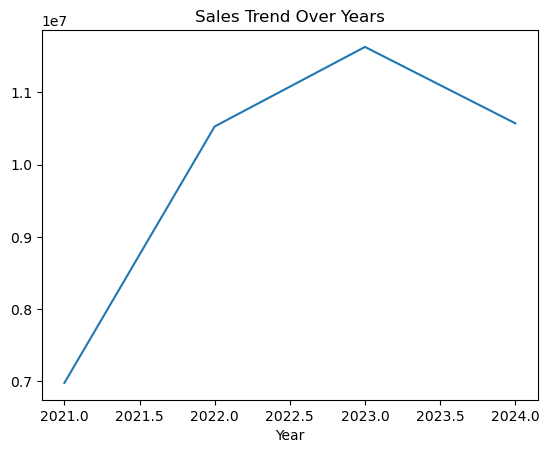

In [52]:
import matplotlib.pyplot as plt

year_sales = df.groupby("Year")["Total_Sales"].sum()

year_sales.plot(kind="line")
plt.title("Sales Trend Over Years")
plt.savefig("images(2)/sales_by_region.png", bbox_inches='tight')
plt.show()

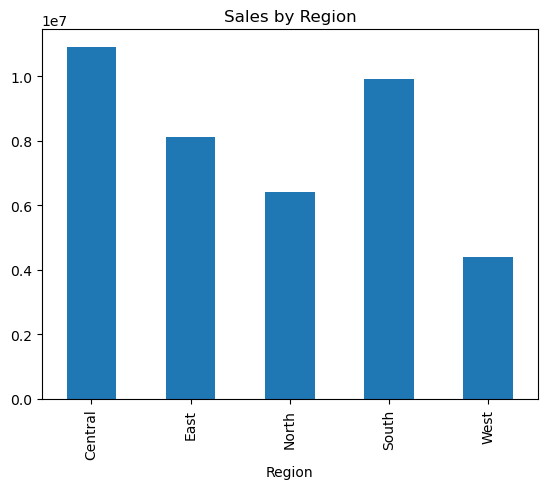

In [50]:
region_sales.plot(kind="bar")
plt.title("Sales by Region")

plt.savefig("images(2)/sales_by_region.png", bbox_inches='tight')
plt.show()

In [44]:
numeric_df = df.select_dtypes(include=['number'])

print(numeric_df.corr())

             Order_ID  Units_Sold  Unit_Price      Year  Total_Sales
Order_ID     1.000000    0.105448    0.037917 -0.054415     0.090873
Units_Sold   0.105448    1.000000    0.063895  0.026580     0.536637
Unit_Price   0.037917    0.063895    1.000000  0.134156     0.829043
Year        -0.054415    0.026580    0.134156  1.000000     0.150953
Total_Sales  0.090873    0.536637    0.829043  0.150953     1.000000


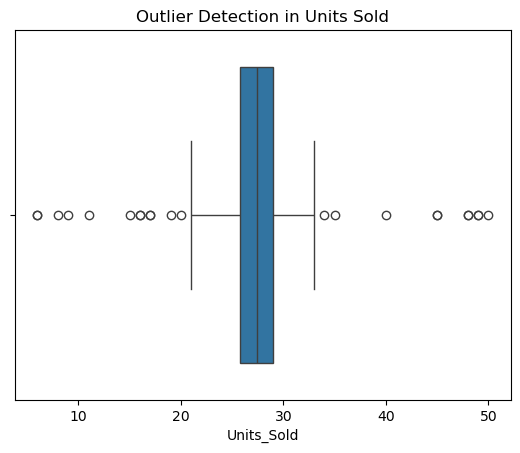

In [42]:
import seaborn as sns

sns.boxplot(x=df["Units_Sold"])
plt.title("Outlier Detection in Units Sold")
plt.show()

## Key Insights

- Certain products generate significantly higher revenue than others.
- Some regions outperform others in total sales contribution.
- Sales trends indicate business growth over the years.
- A few outliers exist in units sold data.
- Unit price impacts overall revenue generation.

## Conclusion

This exploratory data analysis helped identify important sales trends,
regional performance patterns, and revenue-driving products.
The analysis demonstrates how raw business data can be transformed
into actionable insights using Python and visualization tools.